In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import dotenv_values
from urllib.parse import quote_plus

# ---- Load .env ----
config = dotenv_values()
pg_user = config['POSTGRES_USER']
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = quote_plus(config['POSTGRES_PASS'])

# ---- Create Engine ----
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'
engine = create_engine(url, echo=False)

pg_user

python-dotenv could not parse statement starting at line 1


'nicolebrueggmann'

python-dotenv could not parse statement starting at line 1


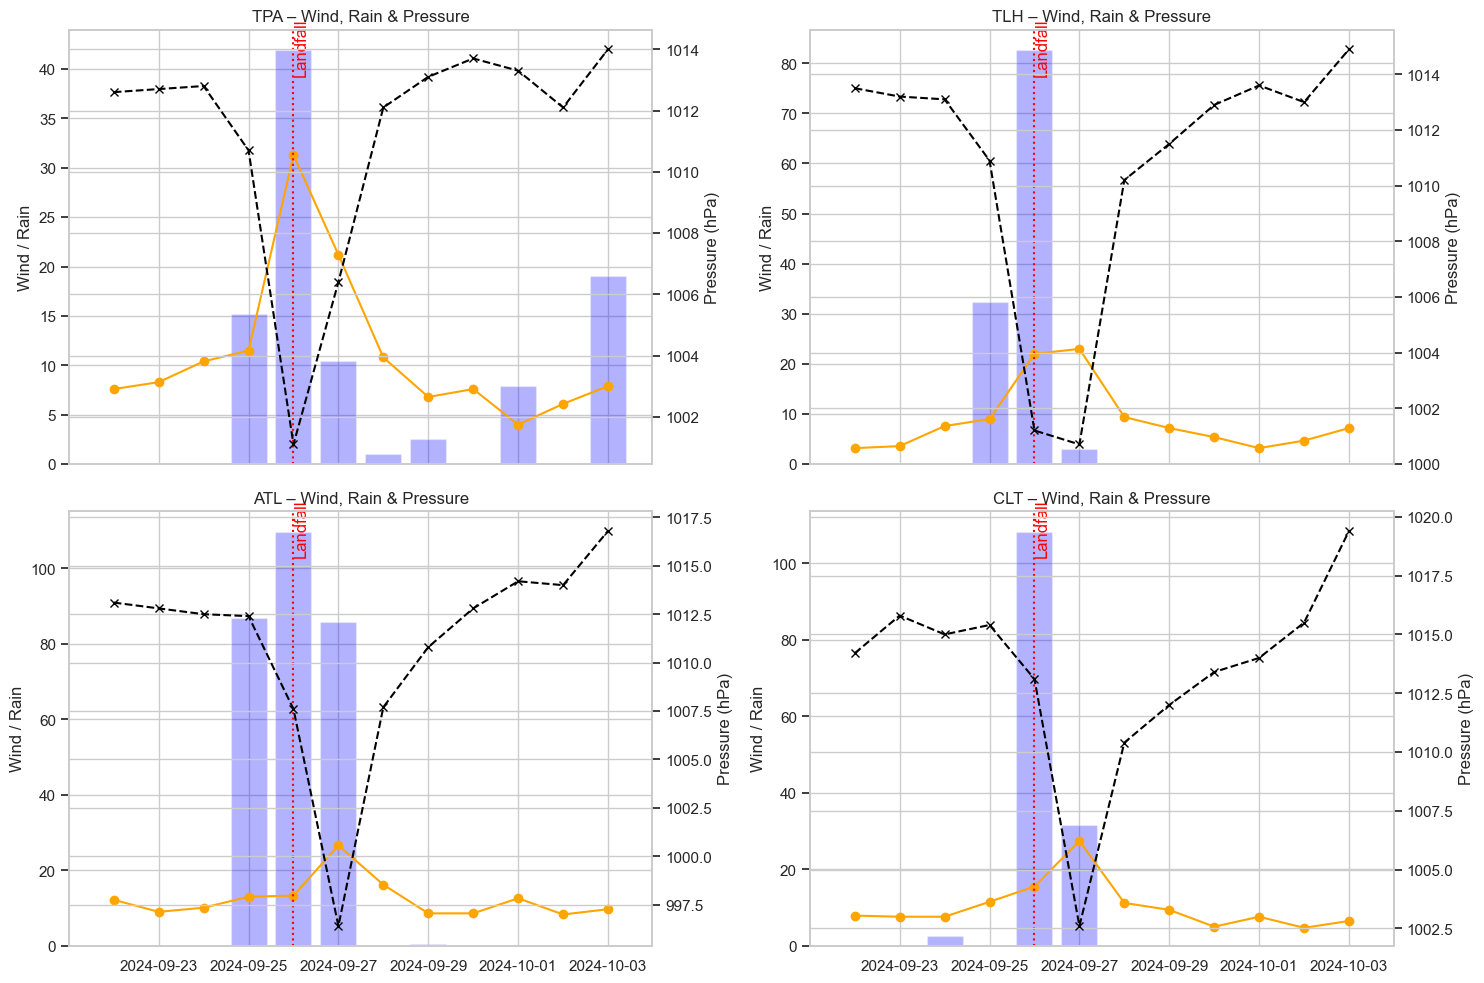

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import dotenv_values
from urllib.parse import quote_plus

# ---- Load .env ----
config = dotenv_values()
pg_user = config['POSTGRES_USER']
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = quote_plus(config['POSTGRES_PASS'])

# ---- Create Engine ----
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'
engine = create_engine(url, echo=False)

# ---- Load Data ----
query = f"""
SELECT airport_code,
       date,
       avg_wind_speed_kmh,
       precipitation_mm,
       avg_pressure_hpa
FROM {pg_schema}.prep_weather_daily
WHERE airport_code IN ('TPA','TLH','ATL','CLT')
  AND date BETWEEN '2024-09-22' AND '2024-10-03'
ORDER BY airport_code, date
"""
df = pd.read_sql(query, engine)
df['date'] = pd.to_datetime(df['date'])

# ---- Plot Settings ----
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15,10), sharex=True)
axes = axes.flatten()

helene_day = pd.to_datetime("2024-09-26")

for ax, airport in zip(axes, ['TPA','TLH','ATL','CLT']):
    sub = df[df['airport_code'] == airport]

    # Wind line
    ax.plot(sub['date'], sub['avg_wind_speed_kmh'],
            color='orange', marker='o', label='Wind (km/h)')

    # Precipitation bars
    ax.bar(sub['date'], sub['precipitation_mm'],
           alpha=0.3, color='blue', label='Precipitation (mm)')

    # Pressure line on secondary axis
    ax2 = ax.twinx()
    ax2.plot(sub['date'], sub['avg_pressure_hpa'],
             color='black', linestyle='--', marker='x', label='Pressure (hPa)')

    ax.set_title(f"{airport} – Wind, Rain & Pressure")
    ax.set_ylabel("Wind / Rain")
    ax2.set_ylabel("Pressure (hPa)")

    # Highlight Helene landfall
    ax.axvline(helene_day, color='red', linestyle=':', linewidth=1.5)
    ax.text(helene_day, ax.get_ylim()[1]*0.9, 'Landfall', color='red', rotation=90)

plt.tight_layout()

# ---- SAVE PLOT ----
plt.savefig("helene_weather_summary_22_sep_till_03_oct_2024.png", dpi=300, bbox_inches="tight")
plt.show()

python-dotenv could not parse statement starting at line 1


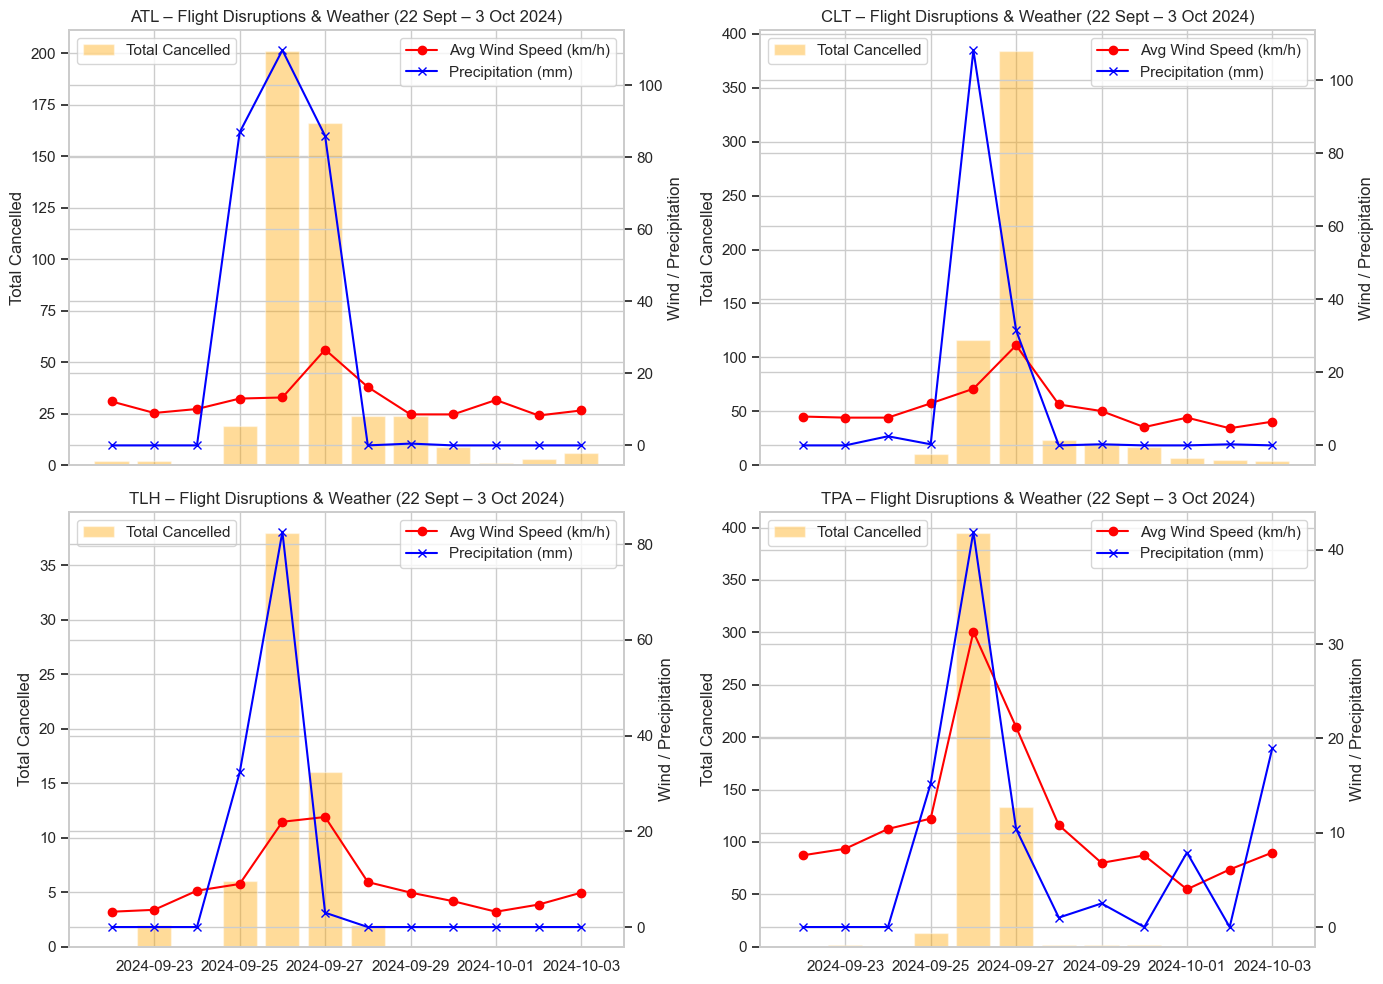

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import dotenv_values

# ---- Load .env ----
config = dotenv_values()
pg_user = config['POSTGRES_USER']
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = quote_plus(config['POSTGRES_PASS'])

# ---- Create engine ----
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'
engine = create_engine(url, echo=False)

# ---- Load daily flights + weather ----
query = f"""
SELECT *
FROM {pg_schema}.mart_daily_flights_weather
WHERE airport IN ('TPA','TLH','ATL','CLT')
  AND flight_date BETWEEN '2024-09-22' AND '2024-10-03'
ORDER BY airport, flight_date
"""
df = pd.read_sql(query, engine)
df['flight_date'] = pd.to_datetime(df['flight_date'])

# ---- Plot ----
sns.set(style="whitegrid")
airports = df['airport'].unique()
fig, axes = plt.subplots(2, 2, figsize=(14,10), sharex=True)
axes = axes.flatten()

for ax, airport in zip(axes, airports):
    sub = df[df['airport'] == airport]
    
    # Bar: total cancelled
    ax.bar(sub['flight_date'], sub['total_cancelled'],
           alpha=0.4, label="Total Cancelled", color='orange')
    
    # Line: wind speed & precipitation
    ax2 = ax.twinx()
    ax2.plot(sub['flight_date'], sub['avg_wind_speed_kmh'],
             color='red', marker='o', label="Avg Wind Speed (km/h)")
    ax2.plot(sub['flight_date'], sub['precipitation_mm'],
             color='blue', marker='x', label="Precipitation (mm)")
    
    ax.set_title(f"{airport} – Flight Disruptions & Weather (22 Sept – 3 Oct 2024)")
    ax.set_ylabel("Total Cancelled")
    ax2.set_ylabel("Wind / Precipitation")
    
    # Legends
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig("flight_weather_summary.png", dpi=300)
plt.show()

python-dotenv could not parse statement starting at line 1
/var/folders/44/4bwz988s0nz2kzlgp5nnzdl80000gn/T/ipykernel_18668/848750922.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left')


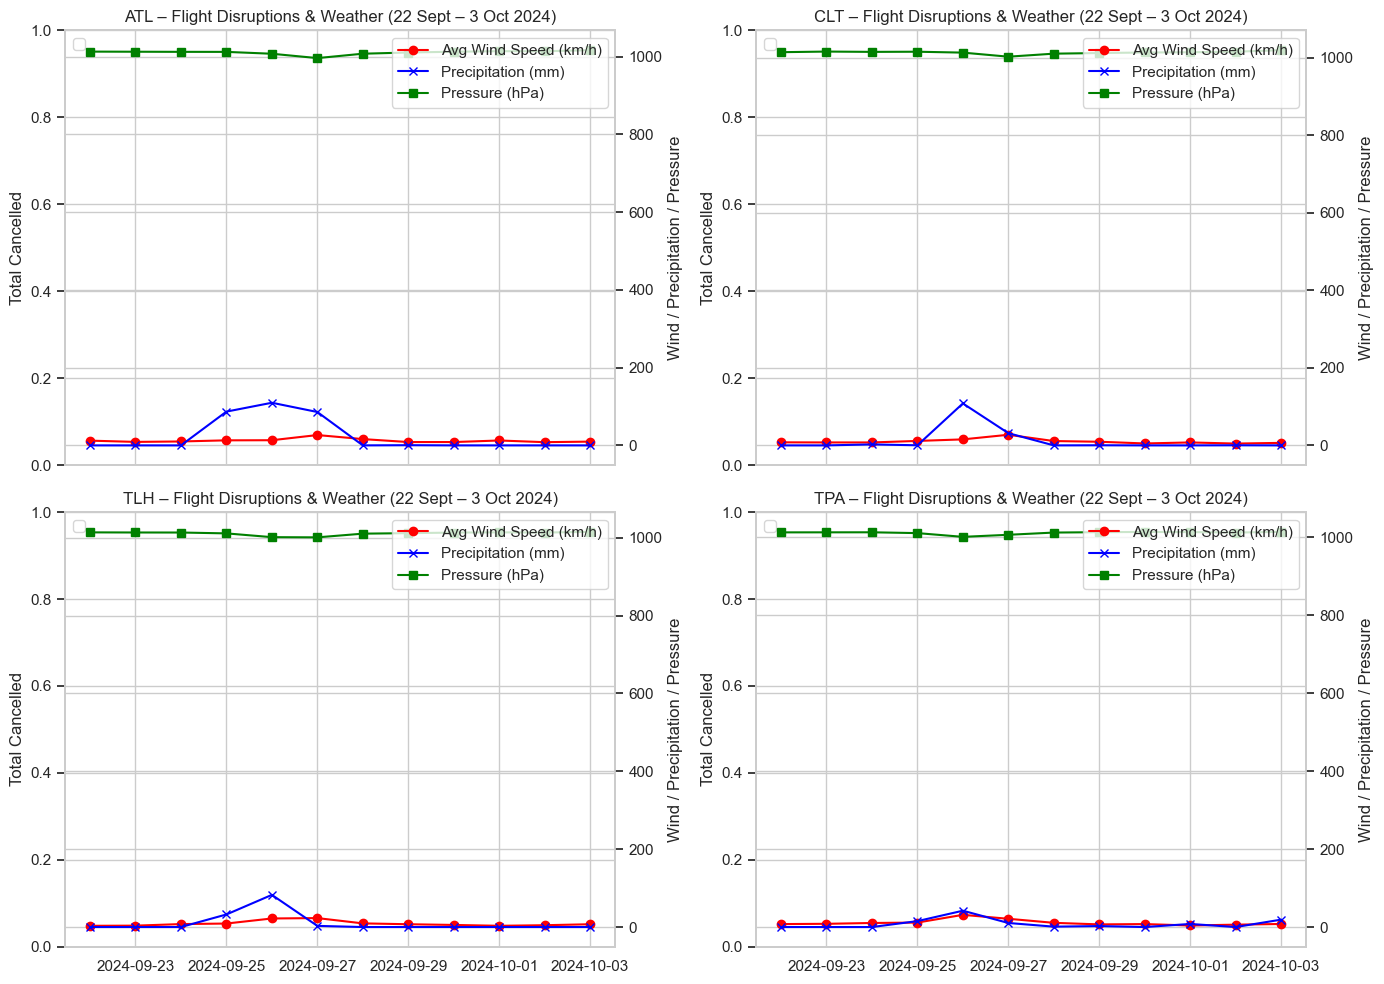

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import dotenv_values

# ---- Load .env ----
config = dotenv_values()
pg_user = config['POSTGRES_USER']
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = quote_plus(config['POSTGRES_PASS'])

# ---- Create engine ----
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'
engine = create_engine(url, echo=False)

# ---- Load daily flights + weather ----
query = f"""
SELECT *
FROM {pg_schema}.prep_weather_daily
WHERE airport_code IN ('TPA','TLH','ATL','CLT')
  AND date BETWEEN '2024-09-22' AND '2024-10-03'
ORDER BY airport_code, date
"""
df = pd.read_sql(query, engine)
df['date'] = pd.to_datetime(df['date'])

# ---- Plot ----
sns.set(style="whitegrid")
airports = df['airport_code'].unique()
fig, axes = plt.subplots(2, 2, figsize=(14,10), sharex=True)
axes = axes.flatten()

for ax, airport in zip(axes, airports):
    sub = df[df['airport_code'] == airport]
    
    # Bar: total cancelled (here using total_cancelled if available, else dep_cancelled + arr_cancelled)
    if 'total_cancelled' in sub.columns:
        cancelled_col = 'total_cancelled'
    elif 'dep_cancelled' in sub.columns and 'arr_cancelled' in sub.columns:
        cancelled_col = sub['dep_cancelled'] + sub['arr_cancelled']
    else:
        cancelled_col = None
    
    if cancelled_col is not None:
        ax.bar(sub['date'], sub[cancelled_col],
               alpha=0.4, label="Total Cancelled", color='orange')
    
    # Line: wind speed, precipitation, pressure
    ax2 = ax.twinx()
    ax2.plot(sub['date'], sub['avg_wind_speed_kmh'],
             color='red', marker='o', label="Avg Wind Speed (km/h)")
    ax2.plot(sub['date'], sub['precipitation_mm'],
             color='blue', marker='x', label="Precipitation (mm)")
    ax2.plot(sub['date'], sub['avg_pressure_hpa'],
             color='green', marker='s', label="Pressure (hPa)")
    
    ax.set_title(f"{airport} – Flight Disruptions & Weather (22 Sept – 3 Oct 2024)")
    ax.set_ylabel("Total Cancelled")
    ax2.set_ylabel("Wind / Precipitation / Pressure")
    
    # Legends
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig("daily_flight_weather_summary.png", dpi=300)
plt.show()

python-dotenv could not parse statement starting at line 1


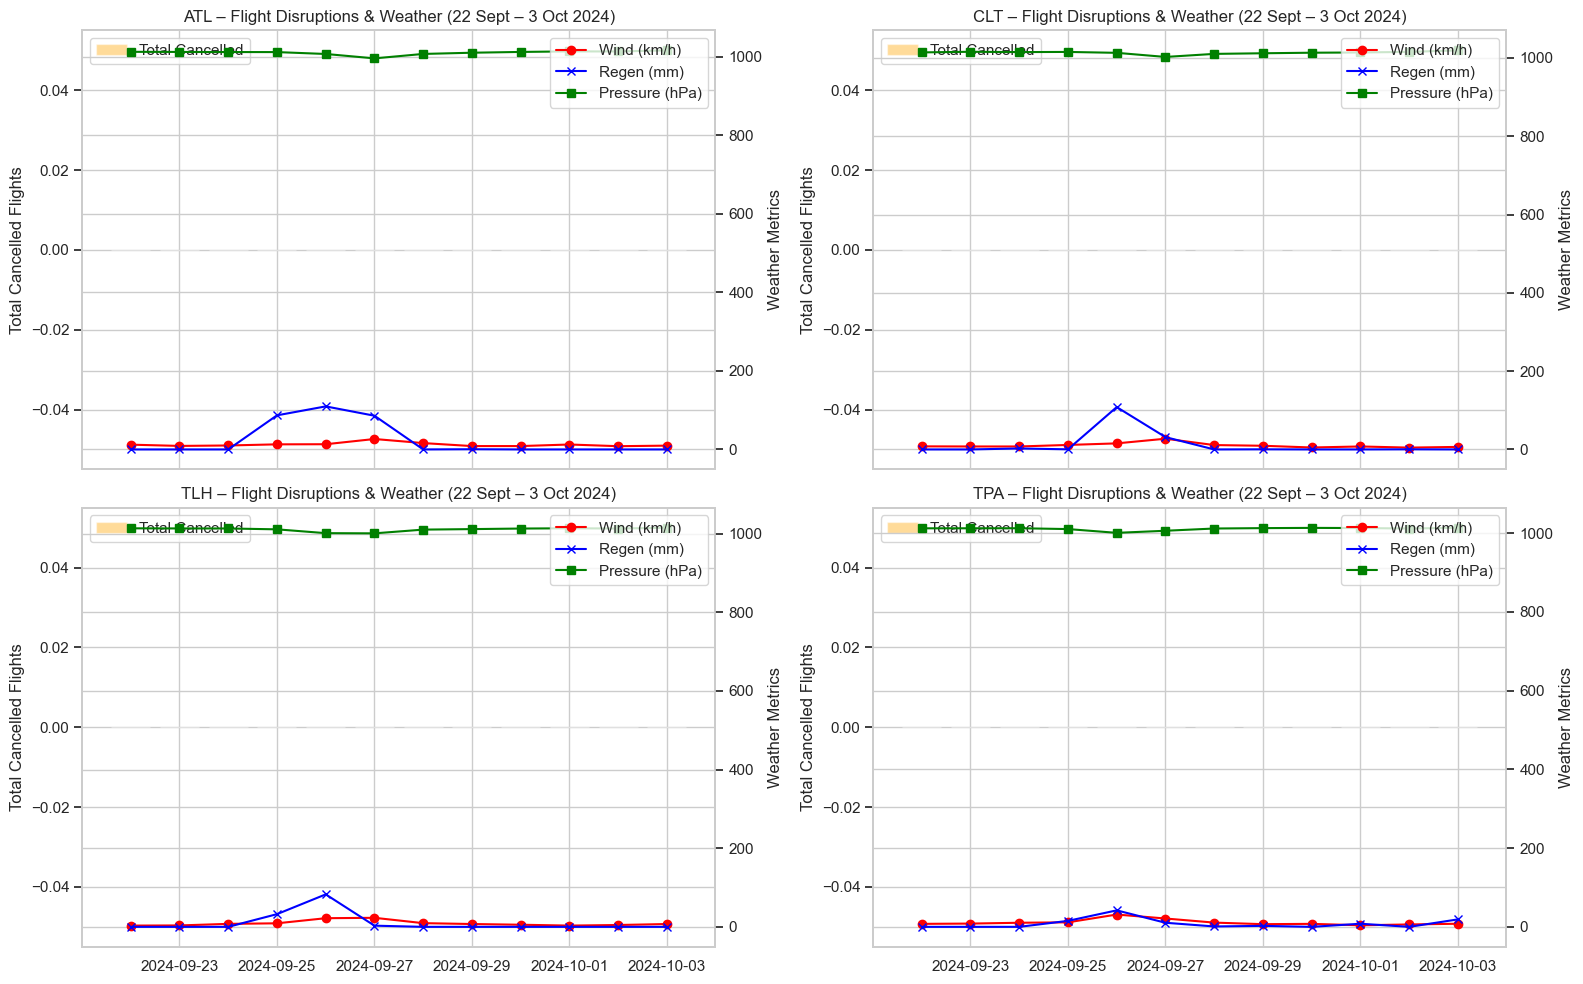

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import dotenv_values

# ---- Load environment variables ----
config = dotenv_values()  # make sure .env has correct keys

pg_user = config['POSTGRES_USER']
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db   = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']  # z.B. below_zero
pg_pass = quote_plus(config['POSTGRES_PASS'])

# ---- Create SQLAlchemy engine ----
url = f"postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}"
engine = create_engine(url, echo=False)

# ---- Load daily flights + weather from schema ----
query = f"""
SELECT *
FROM {pg_schema}.prep_weather_daily
WHERE airport_code IN ('TPA','TLH','ATL','CLT')
  AND date BETWEEN '2024-09-22' AND '2024-10-03'
ORDER BY airport_code, date
"""

df = pd.read_sql(query, engine)

# ---- Prepare Data ----
df['date'] = pd.to_datetime(df['date'])

# Check if cancelled columns exist
if 'dep_cancelled' in df.columns and 'arr_cancelled' in df.columns:
    df['total_cancelled'] = df['dep_cancelled'] + df['arr_cancelled']
else:
    # fallback if these columns don't exist
    df['total_cancelled'] = 0

# Rename weather columns for easier plotting
rename_dict = {}
if 'avg_wind_speed_kmh' in df.columns:
    rename_dict['avg_wind_speed_kmh'] = 'wind_kmh'
if 'precipitation_mm' in df.columns:
    rename_dict['precipitation_mm'] = 'rain_mm'
if 'avg_pressure_hpa' in df.columns:
    rename_dict['avg_pressure_hpa'] = 'pressure_hpa'

df.rename(columns=rename_dict, inplace=True)

# ---- Plot Settings ----
sns.set(style="whitegrid")
airports = df['airport_code'].unique()

fig, axes = plt.subplots(2, 2, figsize=(16,10), sharex=True)
axes = axes.flatten()

for ax, airport in zip(axes, airports):
    sub = df[df['airport_code'] == airport]

    # Bar: total cancelled flights
    ax.bar(sub['date'], sub['total_cancelled'], alpha=0.4, label='Total Cancelled', color='orange')

    # Line: weather variables
    ax2 = ax.twinx()
    if 'wind_kmh' in sub.columns:
        ax2.plot(sub['date'], sub['wind_kmh'], color='red', marker='o', label='Wind (km/h)')
    if 'rain_mm' in sub.columns:
        ax2.plot(sub['date'], sub['rain_mm'], color='blue', marker='x', label='Regen (mm)')
    if 'pressure_hpa' in sub.columns:
        ax2.plot(sub['date'], sub['pressure_hpa'], color='green', marker='s', label='Pressure (hPa)')

    # Titles & labels
    ax.set_title(f"{airport} – Flight Disruptions & Weather (22 Sept – 3 Oct 2024)")
    ax.set_ylabel("Total Cancelled Flights")
    ax2.set_ylabel("Weather Metrics")
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

plt.tight_layout()

# ---- Save Plot ----
plt.savefig("daily_flights_weather.png", dpi=300)
plt.show()

python-dotenv could not parse statement starting at line 1


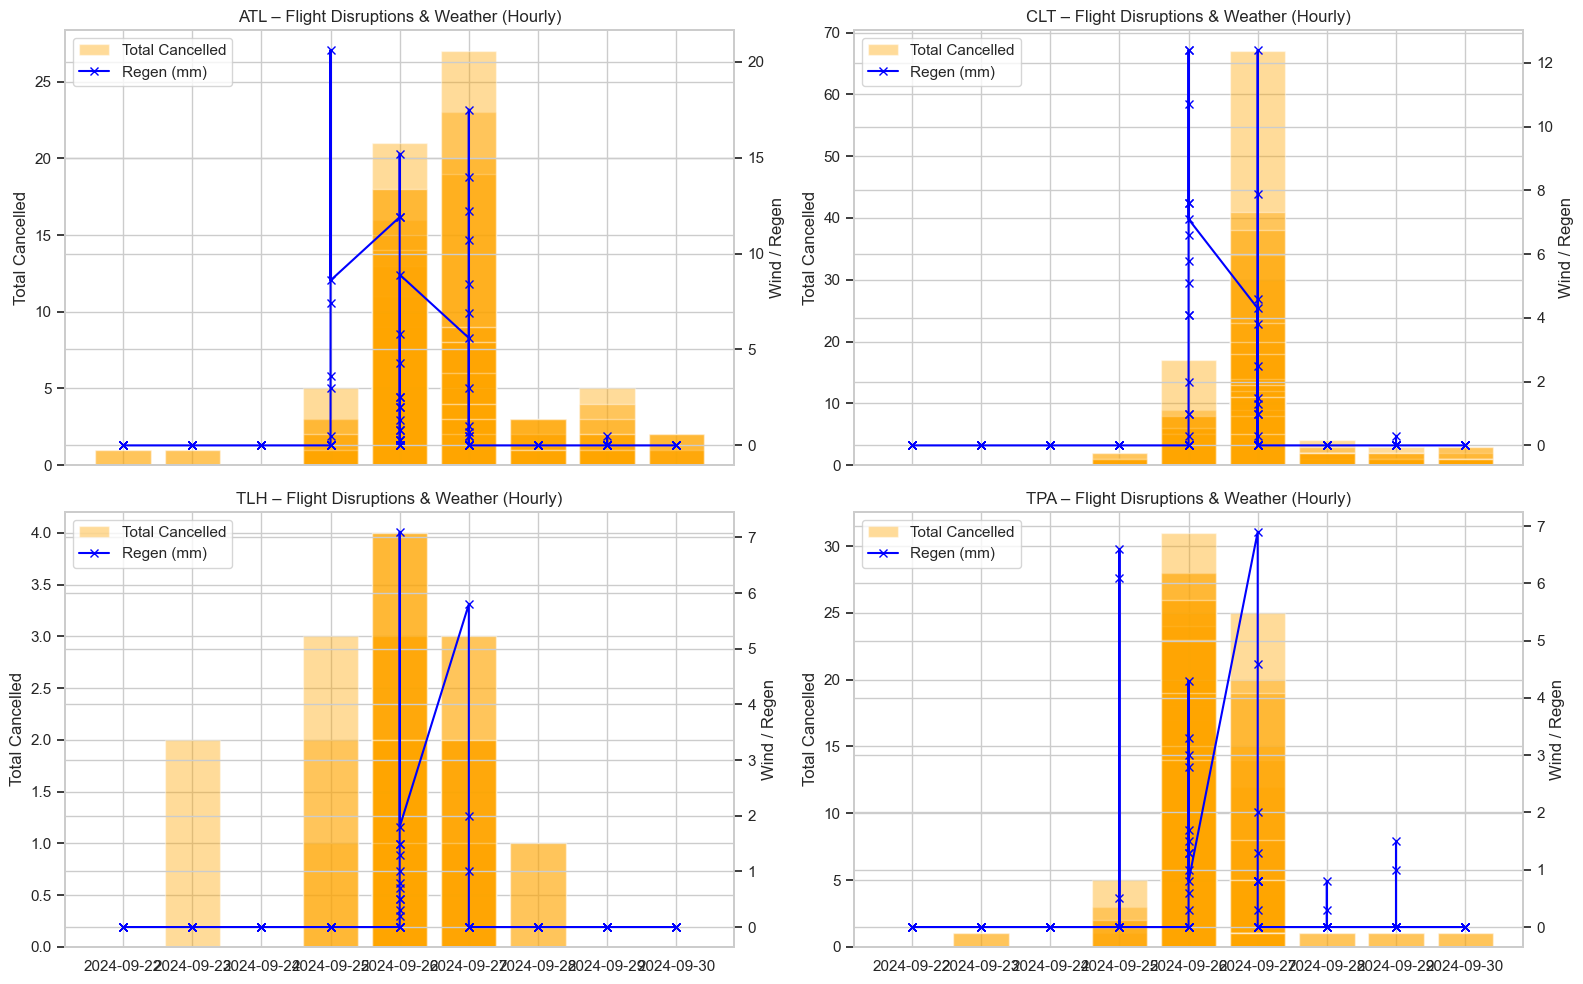

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import dotenv_values
from urllib.parse import quote_plus

# ---- Load .env ----
config = dotenv_values()
pg_user = config['POSTGRES_USER']
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = quote_plus(config['POSTGRES_PASS'])

# ---- Create Engine ----
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'
engine = create_engine(url, echo=False)

# ---- Load hourly flights + weather (22 Sept – 3 Oct 2024) ----
# Passe das datetime Feld hier ggf. an
query = f"""
SELECT *
FROM {pg_schema}.mart_hourly_flights_weather
WHERE airport IN ('TPA','TLH','ATL','CLT')
  AND flight_date BETWEEN '2024-09-22' AND '2024-10-03'
ORDER BY airport, flight_date
"""

df = pd.read_sql(query, engine)

# ---- Prepare Data ----
df['flight_date'] = pd.to_datetime(df['flight_date'])

# Falls ein datetime-Feld existiert, sonst nur flight_date + hour kombinieren
if 'flight_hour' in df.columns:
    df['datetime'] = df['flight_date'] + pd.to_timedelta(df['flight_hour'], unit='h')
elif 'flight_datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['flight_datetime'])
else:
    # fallback: nur flight_date
    df['datetime'] = df['flight_date']

# Compute total cancelled per hour if not present
if 'total_cancelled' not in df.columns:
    df['total_cancelled'] = df['dep_cancelled'] + df['arr_cancelled']

# ---- Plot Settings ----
sns.set(style="whitegrid")
airports = df['airport'].unique()

fig, axes = plt.subplots(2, 2, figsize=(16,10), sharex=True)
axes = axes.flatten()

for ax, airport in zip(axes, airports):
    sub = df[df['airport'] == airport]

    # Bar: total cancelled
    ax.bar(sub['datetime'], sub['total_cancelled'],
           alpha=0.4, label="Total Cancelled", color='orange')

    # Line: wind, rain
    ax2 = ax.twinx()
    if 'avg_wind_speed_kmh' in sub.columns:
        ax2.plot(sub['datetime'], sub['avg_wind_speed_kmh'],
                 color='red', marker='o', label="Wind (km/h)")
    if 'precipitation_mm' in sub.columns:
        ax2.plot(sub['datetime'], sub['precipitation_mm'],
                 color='blue', marker='x', label="Regen (mm)")

    ax.set_title(f"{airport} – Flight Disruptions & Weather (Hourly)")
    ax.set_ylabel("Total Cancelled")
    ax2.set_ylabel("Wind / Regen")

    # Combine legends
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig("new_hourly_flights_weather.png", dpi=300)  # Speichert mit hoher Auflösung
plt.show()

python-dotenv could not parse statement starting at line 1


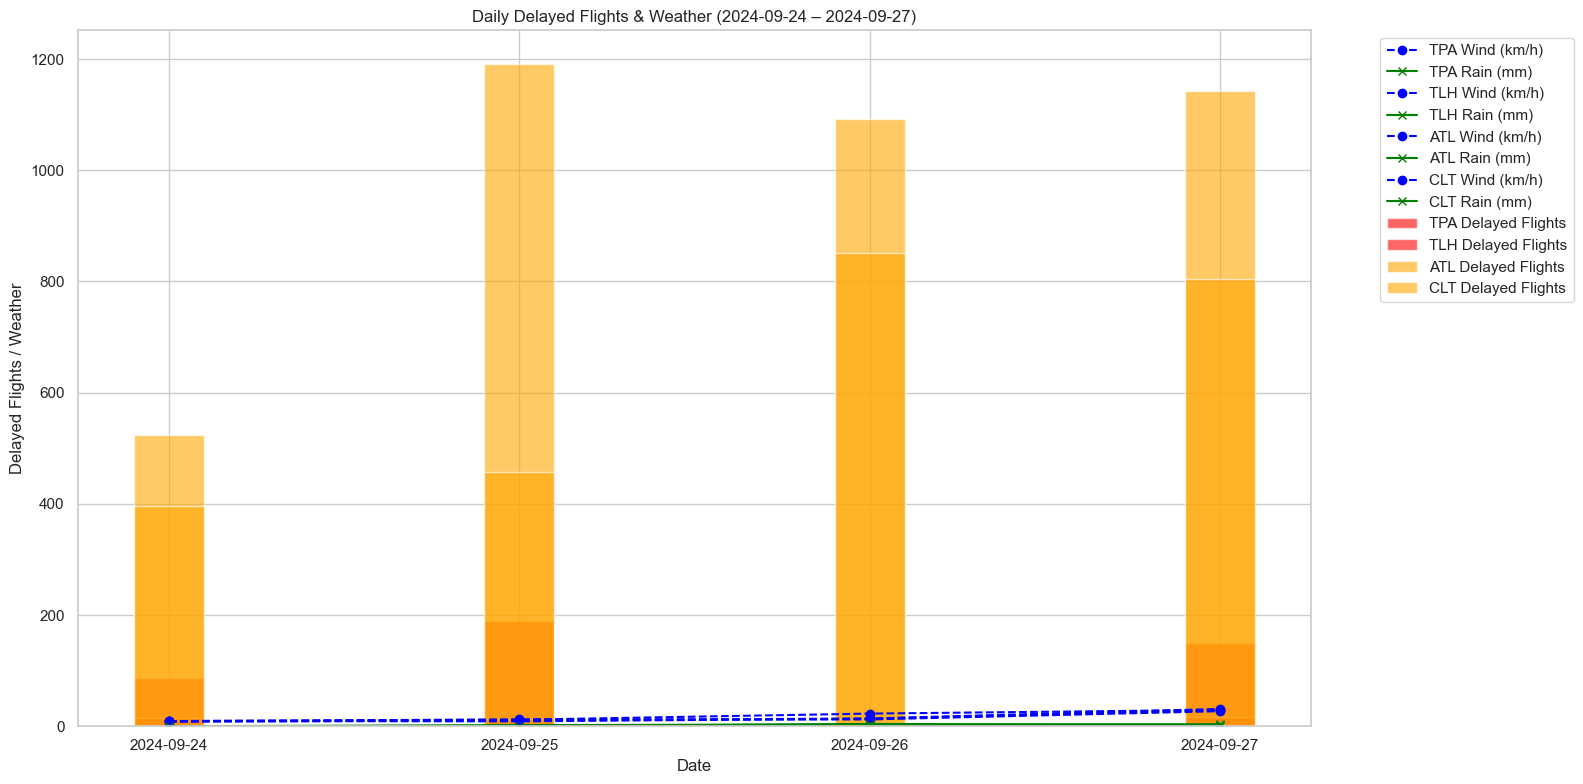

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import dotenv_values
import os

# ---- Load .env ----
config = dotenv_values()  # .env im aktuellen Verzeichnis
pg_user = config['POSTGRES_USER']
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = quote_plus(config['POSTGRES_PASS'])

# ---- Create Engine ----
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'
engine = create_engine(url, echo=False)

# ---- Airports & Date Range ----
airports = ['TPA','TLH','ATL','CLT']
start_date = '2024-09-24'
end_date = '2024-09-27'

# ---- Load hourly flights + weather ----
query = f"""
SELECT *
FROM {pg_schema}.mart_hourly_flights_weather
WHERE airport IN ('{"','".join(airports)}')
  AND flight_date BETWEEN '{start_date}' AND '{end_date}'
ORDER BY airport, flight_date
"""
df = pd.read_sql(query, engine)

# ---- Ensure dep_scheduled is datetime ----
if not np.issubdtype(df['dep_scheduled'].dtype, np.datetime64):
    df['dep_scheduled'] = pd.to_datetime(df['dep_scheduled'], errors='coerce')

# ---- Daily Aggregation ----
daily_summary = df.groupby(['airport', 'flight_date']).agg({
    'dep_delayed_flight':'sum',
    'arr_delayed_flight':'sum',
    'precipitation_mm':'mean',
    'wind_speed_kmh':'mean'
}).reset_index()

daily_summary['total_delayed'] = daily_summary['dep_delayed_flight'] + daily_summary['arr_delayed_flight']

# ---- Plot ----
sns.set(style="whitegrid")
plt.figure(figsize=(16,8))

colors = {'TPA':'red','TLH':'red','ATL':'orange','CLT':'orange'}

for airport in airports:
    sub = daily_summary[daily_summary['airport'] == airport]
    
    # Bar: delayed flights
    plt.bar(sub['flight_date'] + pd.to_timedelta(airports.index(airport)*0.2, unit='d'),
            sub['total_delayed'],
            width=0.2,
            alpha=0.6,
            color=colors[airport],
            label=f"{airport} Delayed Flights")
    
    # Line: wind speed
    plt.plot(sub['flight_date'],
             sub['wind_speed_kmh'],
             color='blue', marker='o', linestyle='--',
             label=f"{airport} Wind (km/h)")
    
    # Line: precipitation
    if 'precipitation_mm' in sub.columns:
        plt.plot(sub['flight_date'],
                 sub['precipitation_mm'],
                 color='green', marker='x', linestyle='-',
                 label=f"{airport} Rain (mm)")

plt.xlabel("Date")
plt.ylabel("Delayed Flights / Weather")
plt.title(f"Daily Delayed Flights & Weather ({start_date} – {end_date})")
plt.xticks(pd.date_range(start=start_date, end=end_date))
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()

# ---- Save Figure ----
os.makedirs("Nicole_test", exist_ok=True)
plt.savefig("Nicole_test/daily_flights_weather_24-27_sep.png", dpi=300)
plt.show()

python-dotenv could not parse statement starting at line 1


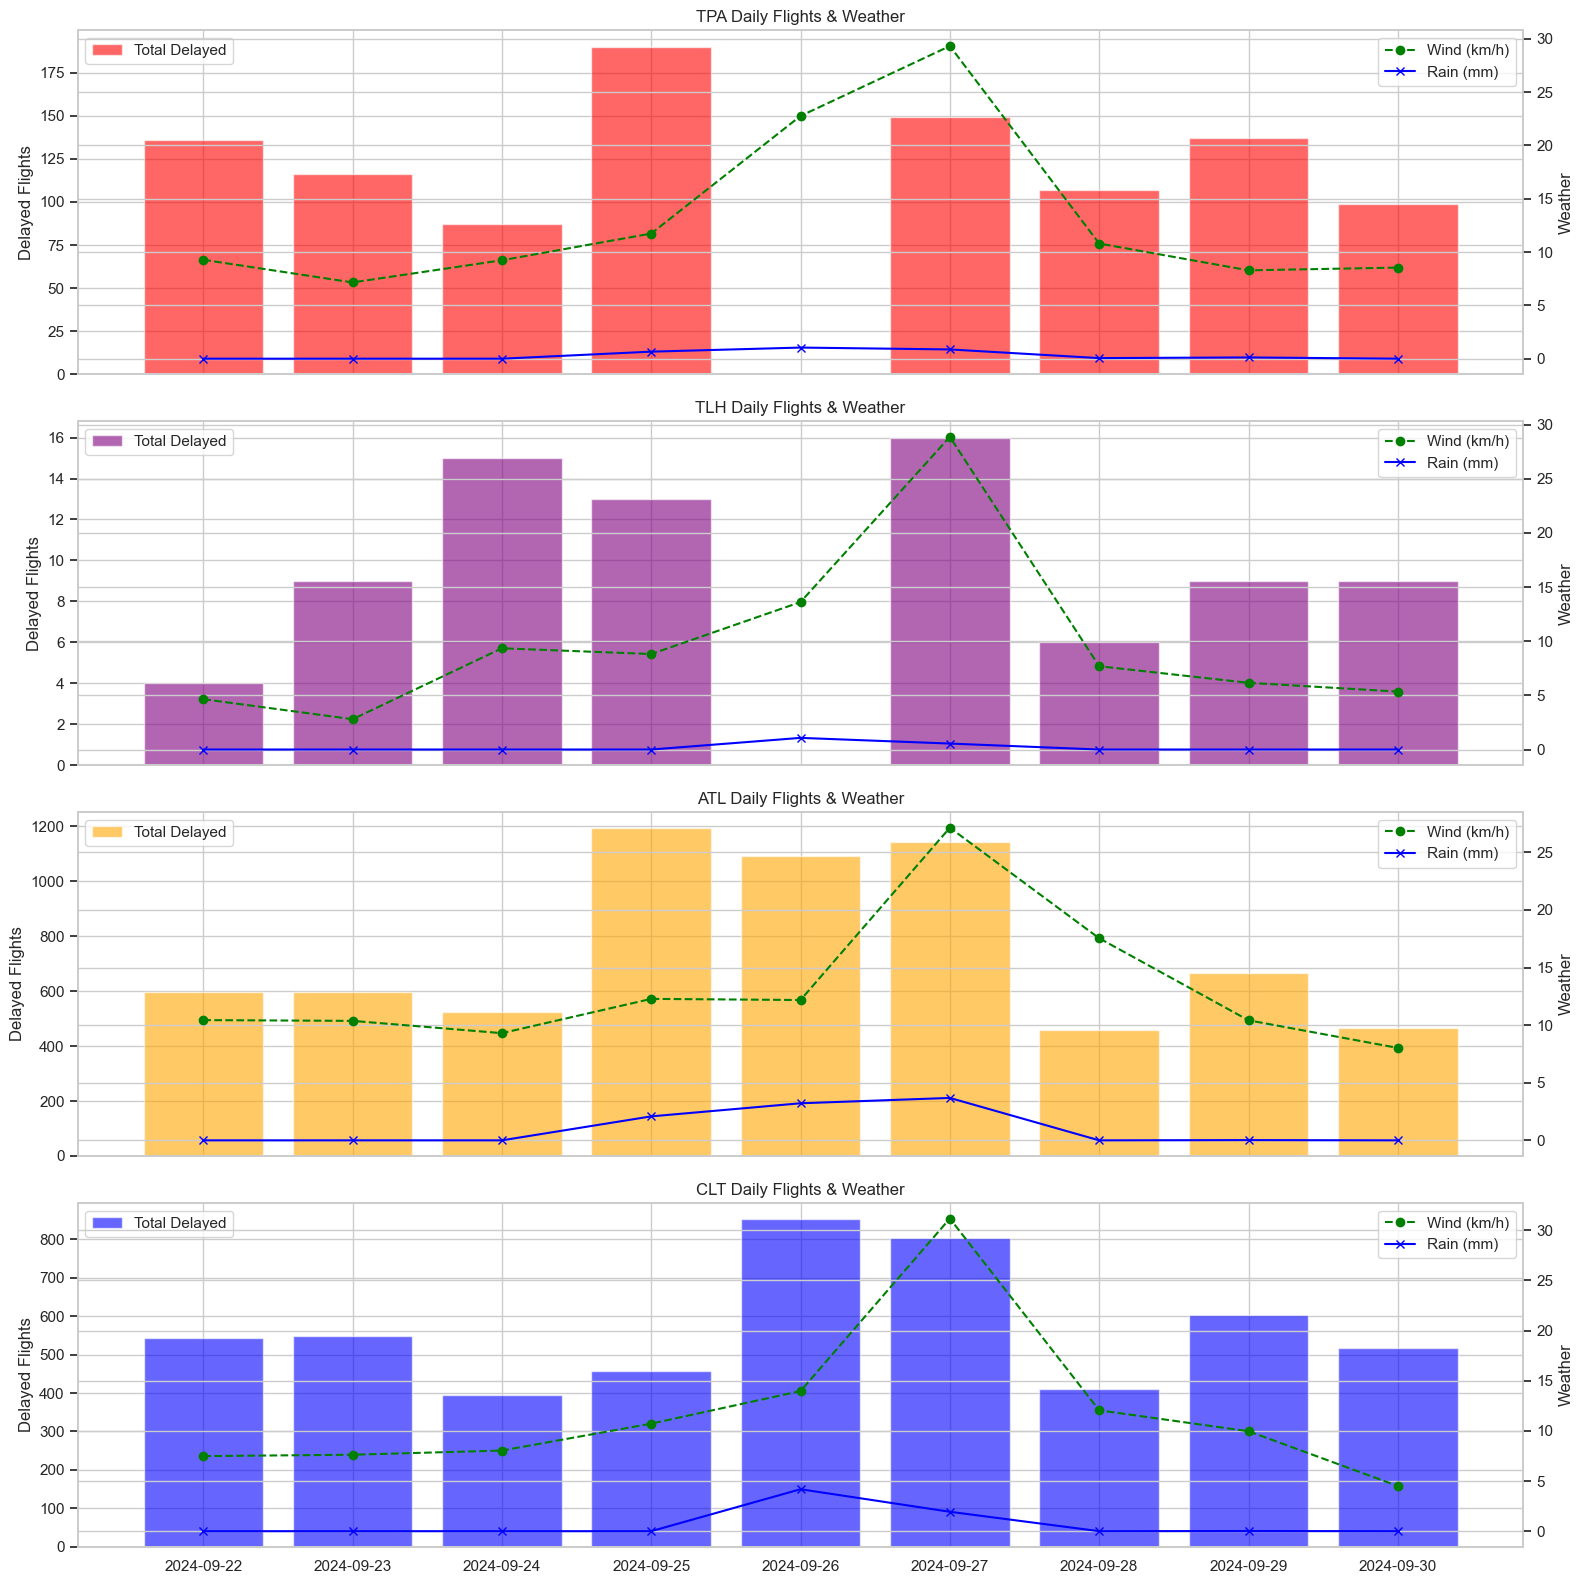

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import dotenv_values
import os

# ---- Load .env ----
config = dotenv_values()
pg_user = config['POSTGRES_USER']
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = quote_plus(config['POSTGRES_PASS'])

# ---- Create Engine ----
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'
engine = create_engine(url, echo=False)

# ---- Airports & Date Range ----
airports = ['TPA','TLH','ATL','CLT']
start_date = '2024-09-22'
end_date = '2024-10-03'

# ---- Load data ----
query = f"""
SELECT *
FROM {pg_schema}.mart_hourly_flights_weather
WHERE airport IN ('{"','".join(airports)}')
  AND flight_date BETWEEN '{start_date}' AND '{end_date}'
ORDER BY airport, flight_date
"""
df = pd.read_sql(query, engine)

# ---- Ensure datetime ----
if not np.issubdtype(df['dep_scheduled'].dtype, np.datetime64):
    df['dep_scheduled'] = pd.to_datetime(df['dep_scheduled'], errors='coerce')

# ---- Daily Aggregation ----
daily_summary = df.groupby(['airport', 'flight_date']).agg({
    'dep_delayed_flight':'sum',
    'arr_delayed_flight':'sum',
    'precipitation_mm':'mean',
    'wind_speed_kmh':'mean'
}).reset_index()

daily_summary['total_delayed'] = daily_summary['dep_delayed_flight'] + daily_summary['arr_delayed_flight']

# ---- Plot: Subplots pro Airport ----
sns.set(style="whitegrid")
fig, axes = plt.subplots(len(airports), 1, figsize=(16, 4*len(airports)), sharex=True)

colors = {'TPA':'red','TLH':'purple','ATL':'orange','CLT':'blue'}

for i, airport in enumerate(airports):
    ax = axes[i]
    sub = daily_summary[daily_summary['airport'] == airport]
    
    # Bar: total delayed
    ax.bar(sub['flight_date'], sub['total_delayed'], color=colors[airport], alpha=0.6, label="Total Delayed")
    
    # Secondary axis for weather
    ax2 = ax.twinx()
    ax2.plot(sub['flight_date'], sub['wind_speed_kmh'], color='green', marker='o', linestyle='--', label='Wind (km/h)')
    ax2.plot(sub['flight_date'], sub['precipitation_mm'], color='blue', marker='x', linestyle='-', label='Rain (mm)')
    
    ax.set_ylabel("Delayed Flights")
    ax2.set_ylabel("Weather")
    ax.set_title(f"{airport} Daily Flights & Weather")
    
    # Legends
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

plt.xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()

# ---- Save Figure ----
os.makedirs("Nicole_test", exist_ok=True)
plt.savefig("Nicole_test/delayed_daily_flights_weather_22-09_to_03-10.png", dpi=300)
plt.show()

python-dotenv could not parse statement starting at line 1


Columns available: ['airport', 'airport_name', 'city', 'country', 'flight_date', 'dep_scheduled', 'dep_not_cancelled', 'dep_cancelled', 'dep_diverted', 'dep_early_flight', 'dep_on_time_flight', 'dep_delayed_flight', 'dep_del_1h', 'dep_del_2h', 'dep_del_3h', 'dep_del_4h', 'dep_del_5h', 'dep_del_6h', 'dep_del_12h', 'dep_del_24h', 'dep_delayed_1day', 'avg_dep_delay', 'arr_scheduled', 'arr_not_cancelled', 'arr_cancelled', 'arr_diverted', 'arr_early_flight', 'arr_on_time_flight', 'arr_delayed_flight', 'arr_del_1h', 'arr_del_2h', 'arr_del_3h', 'arr_del_4h', 'arr_del_5h', 'arr_del_6h', 'arr_del_12h', 'arr_del_24h', 'arr_delayed_1day', 'avg_arr_delay', 'total_scheduled', 'total_cancelled', 'total_diverted', 'total_not_cancelled', 'airport_status', 'helene_day', 'max_temp_c', 'min_temp_c', 'precipitation_mm', 'max_snow_mm', 'avg_wind_direction', 'avg_wind_speed_kmh', 'wind_peakgust_kmh']


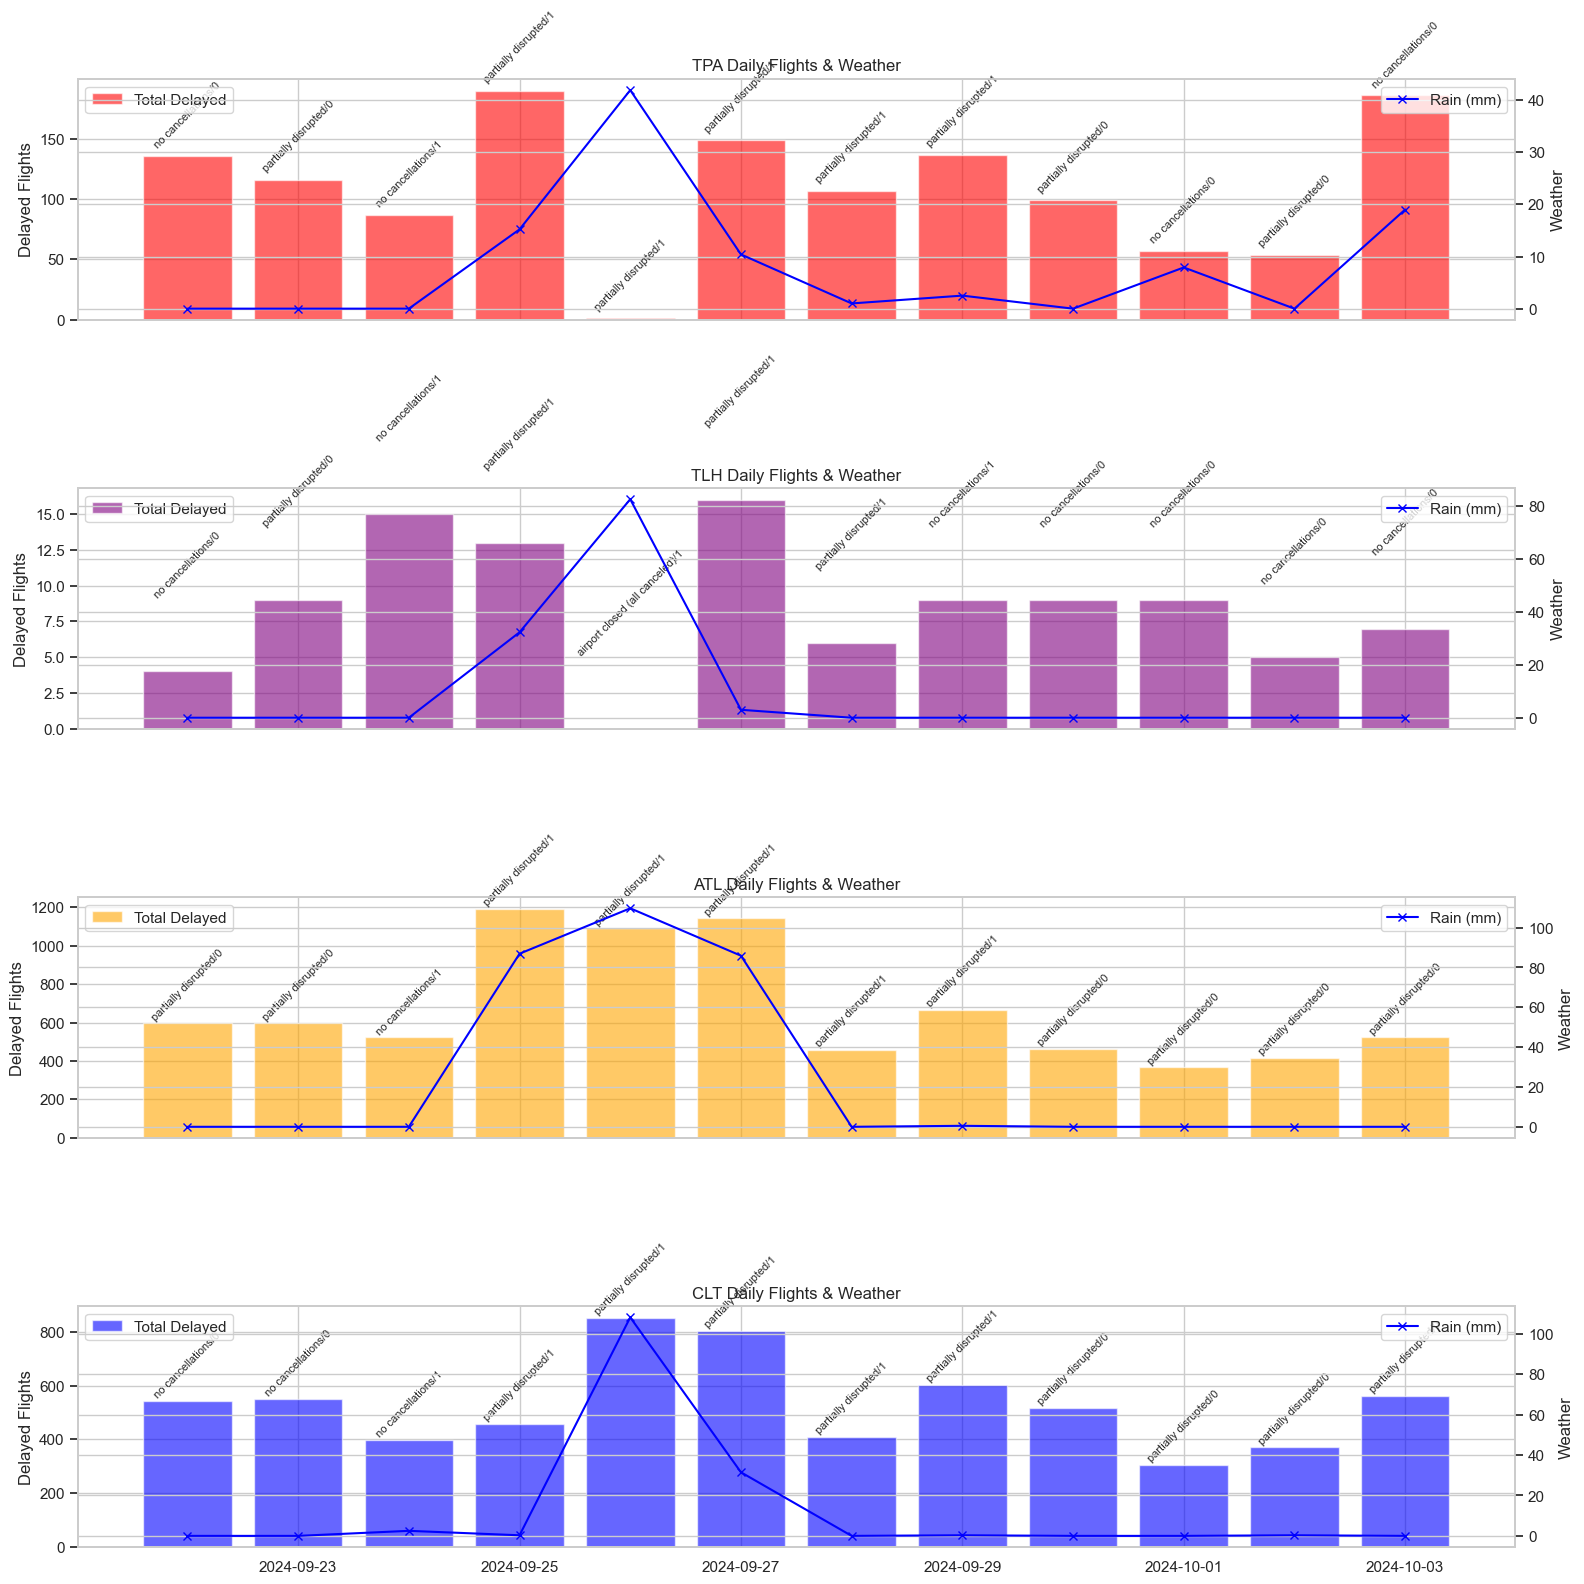

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import dotenv_values
import os

# ---- Load .env ----
config = dotenv_values()
pg_user = config['POSTGRES_USER']
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = quote_plus(config['POSTGRES_PASS'])

# ---- Create Engine ----
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'
engine = create_engine(url, echo=False)

# ---- Airports & Date Range ----
airports = ['TPA','TLH','ATL','CLT']
start_date = '2024-09-22'
end_date = '2024-10-03'

# ---- Load daily flights + weather ----
query = f"""
SELECT *
FROM {pg_schema}.mart_daily_flights_weather
WHERE airport IN ('{"','".join(airports)}')
  AND flight_date BETWEEN '{start_date}' AND '{end_date}'
ORDER BY airport, flight_date
"""
df = pd.read_sql(query, engine)

# ---- Prüfen der Spalten ----
print("Columns available:", df.columns.tolist())

# ---- Optional: flight_date sicherstellen ----
df['flight_date'] = pd.to_datetime(df['flight_date'], errors='coerce')

# ---- Gesamtverzögerungen ----
df['total_delayed'] = df['dep_delayed_flight'] + df['arr_delayed_flight']

# ---- Plot: Subplots pro Airport ----
sns.set(style="whitegrid")
fig, axes = plt.subplots(len(airports), 1, figsize=(16, 4*len(airports)), sharex=True)

colors = {'TPA':'red','TLH':'purple','ATL':'orange','CLT':'blue'}

for i, airport in enumerate(airports):
    ax = axes[i]
    sub = df[df['airport'] == airport]
    
    # Balken: Total Delayed
    ax.bar(sub['flight_date'], sub['total_delayed'], color=colors[airport], alpha=0.6, label="Total Delayed")
    
    # Sekundärachse für Wetter
    ax2 = ax.twinx()
    if 'wind_speed_kmh' in sub.columns:
        ax2.plot(sub['flight_date'], sub['wind_speed_kmh'], color='green', marker='o', linestyle='--', label='Wind (km/h)')
    if 'precipitation_mm' in sub.columns:
        ax2.plot(sub['flight_date'], sub['precipitation_mm'], color='blue', marker='x', linestyle='-', label='Rain (mm)')
    
    # Textannotation: airport_status / Helene_day
    for idx, row in sub.iterrows():
        status_text = ""
        if 'airport_status' in row and pd.notnull(row['airport_status']):
            status_text += str(row['airport_status'])
        if 'helene_day' in row and pd.notnull(row['helene_day']):
            status_text += f"/{row['helene_day']}" if status_text else str(row['helene_day'])
        if status_text:
            ax.text(row['flight_date'], row['total_delayed']+5, status_text,
                    rotation=45, fontsize=8, ha='center', va='bottom')
    
    ax.set_ylabel("Delayed Flights")
    ax2.set_ylabel("Weather")
    ax.set_title(f"{airport} Daily Flights & Weather")
    
    # Legends
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

plt.xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()

# ---- Save Figure ----
os.makedirs("Nicole_test", exist_ok=True)
plt.savefig("Nicole_test/guter plot_helene_day_daily_flights_weather_with_status.png", dpi=300)
plt.show()

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import dotenv_values
import os

# ---- Load .env ----
config = dotenv_values()
pg_user = config['POSTGRES_USER']
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = quote_plus(config['POSTGRES_PASS'])

# ---- Create Engine ----
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'
engine = create_engine(url, echo=False)

# ---- Airports & Date Range ----
airports = ['TPA','TLH','ATL','CLT']
start_date = '2024-09-22'
end_date = '2024-10-03'

# ---- Load daily flights + weather ----
query = f"""
SELECT *
FROM {pg_schema}.mart_daily_flights_weather
WHERE airport IN ('{"','".join(airports)}')
  AND flight_date BETWEEN '{start_date}' AND '{end_date}'
ORDER BY airport, flight_date
"""
df = pd.read_sql(query, engine)

df.head()

python-dotenv could not parse statement starting at line 1


,airport,airport_name,city,country,flight_date,dep_scheduled,dep_not_cancelled,dep_cancelled,dep_diverted,dep_early_flight,...,total_not_cancelled,airport_status,helene_day,max_temp_c,min_temp_c,precipitation_mm,max_snow_mm,avg_wind_direction,avg_wind_speed_kmh,wind_peakgust_kmh
0,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,2024-09-22,1035,1034,1,1,638,...,2068,partially disrupted,0,36.1,22.2,0.0,0,0,12.2,0.0
1,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,2024-09-23,1030,1029,1,5,618,...,2060,partially disrupted,0,35.6,22.8,0.0,0,0,9.0,0.0
2,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,2024-09-24,922,922,0,0,631,...,1843,no cancellations,1,33.9,23.3,0.0,0,0,10.1,0.0
3,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,2024-09-25,926,914,12,3,278,...,1833,partially disrupted,1,30.0,18.9,86.9,0,0,13.0,0.0
4,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,2024-09-26,1031,934,97,2,353,...,1862,partially disrupted,1,23.3,18.9,109.7,0,0,13.3,0.0


python-dotenv could not parse statement starting at line 1
/var/folders/44/4bwz988s0nz2kzlgp5nnzdl80000gn/T/ipykernel_19464/3723035836.py:84: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


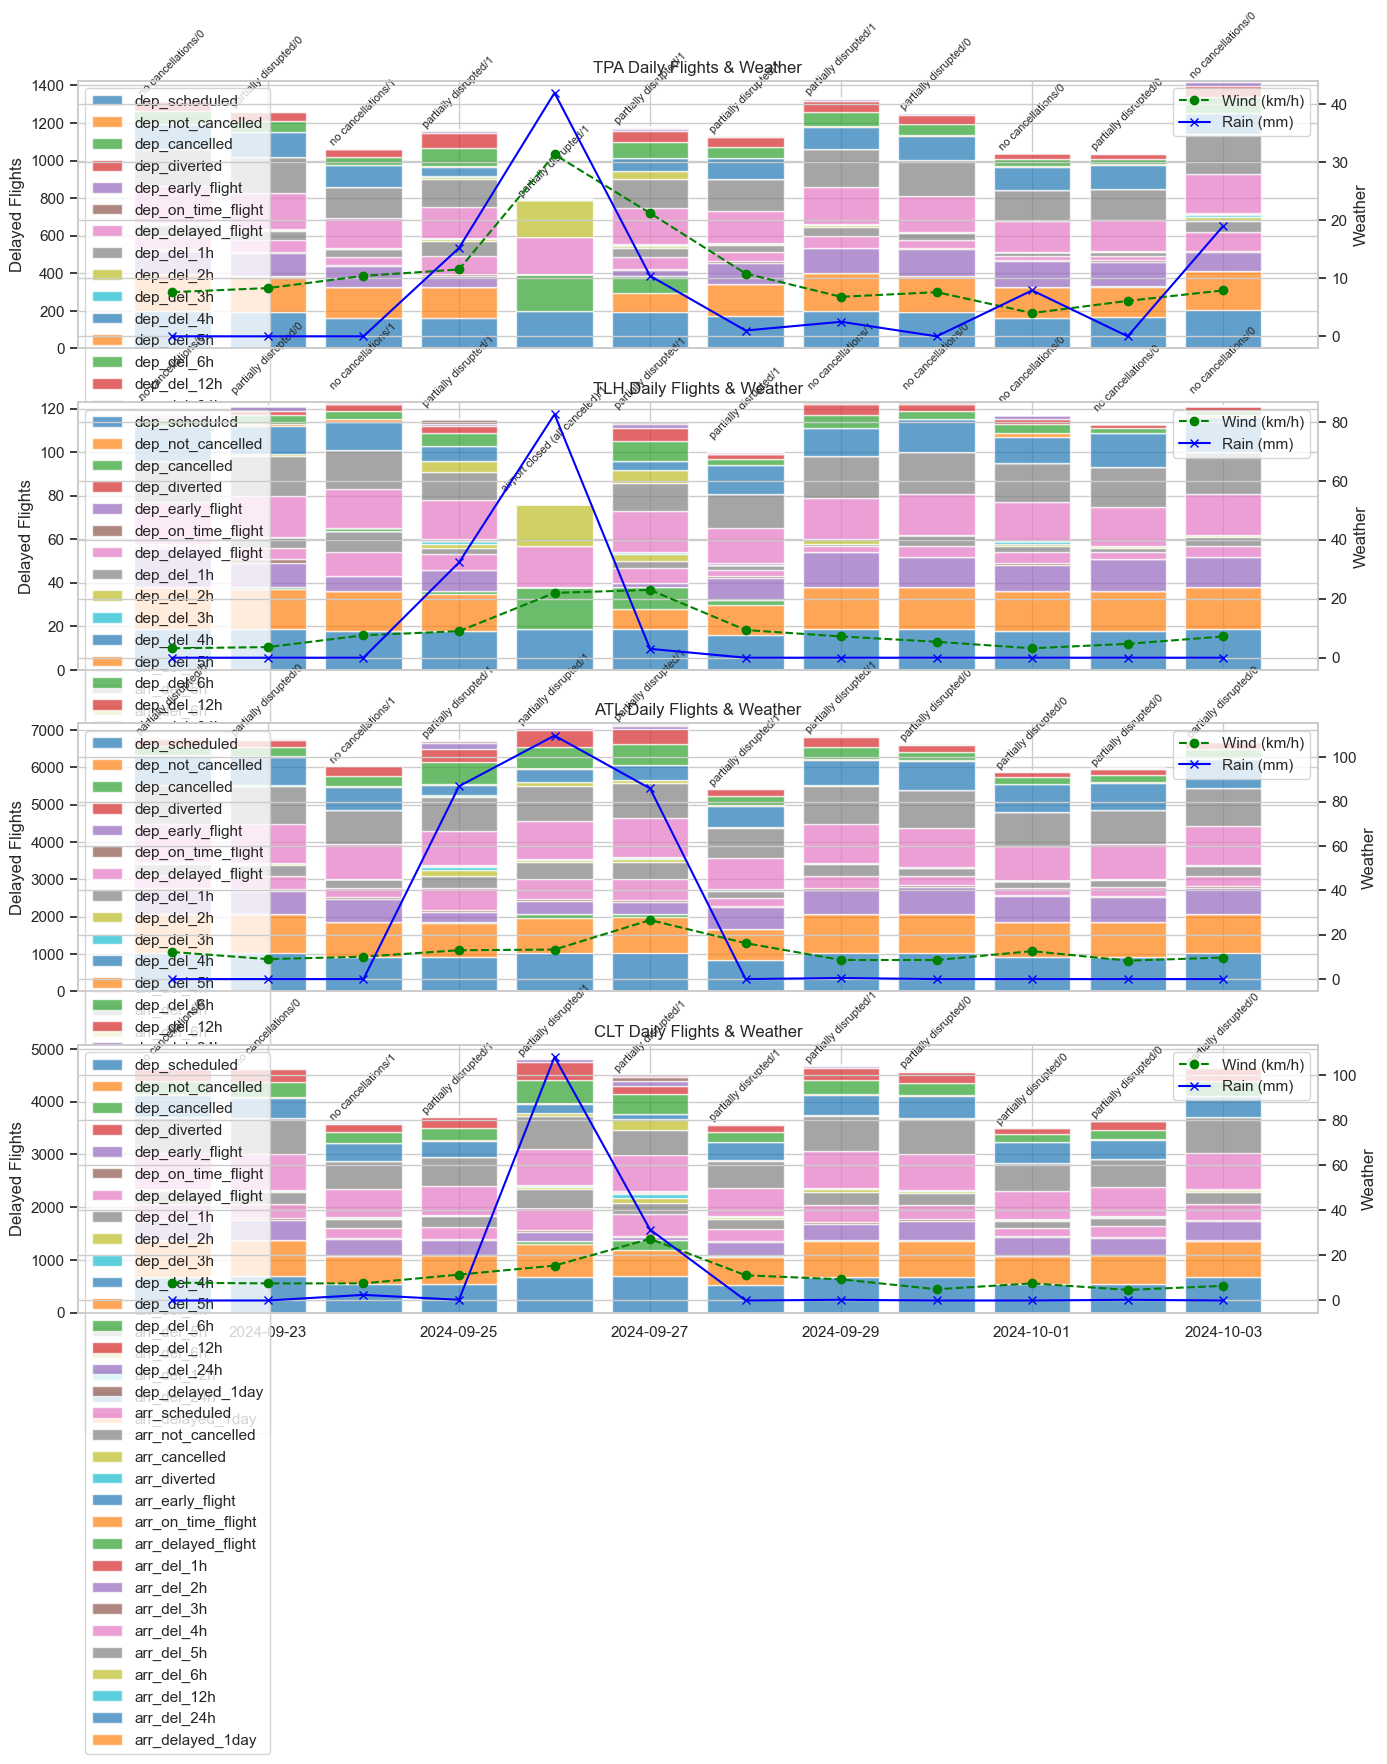

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import dotenv_values
import os

# ---- Load .env ----
config = dotenv_values()
pg_user = config['POSTGRES_USER']
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = quote_plus(config['POSTGRES_PASS'])

# ---- Create Engine ----
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'
engine = create_engine(url, echo=False)

# ---- Airports & Date Range ----
airports = ['TPA','TLH','ATL','CLT']
start_date = '2024-09-22'
end_date = '2024-10-03'

# ---- Load daily flights + weather ----
query = f"""
SELECT *
FROM {pg_schema}.mart_daily_flights_weather
WHERE airport IN ('{"','".join(airports)}')
  AND flight_date BETWEEN '{start_date}' AND '{end_date}'
ORDER BY airport, flight_date
"""
df = pd.read_sql(query, engine)

# ---- Ensure flight_date is datetime ----
df['flight_date'] = pd.to_datetime(df['flight_date'], errors='coerce')

# ---- Identify delay columns dynamically ----
delay_cols = [c for c in df.columns if c.startswith('dep_') or c.startswith('arr_')]

# ---- Plot: Subplots pro Airport ----
sns.set(style="whitegrid")
fig, axes = plt.subplots(len(airports), 1, figsize=(16, 4*len(airports)), sharex=True)

colors = sns.color_palette("tab10", n_colors=len(delay_cols))

for i, airport in enumerate(airports):
    ax = axes[i]
    sub = df[df['airport'] == airport]
    
    # ---- Stacked bars für alle Delay-Spalten ----
    bottom = pd.Series([0]*len(sub), index=sub.index)
    for j, col in enumerate(delay_cols):
        ax.bar(sub['flight_date'], sub[col], bottom=bottom, color=colors[j], alpha=0.7, label=col)
        bottom += sub[col]
    
    # ---- Sekundärachse für Wetter ----
    ax2 = ax.twinx()
    if 'avg_wind_speed_kmh' in sub.columns:
        ax2.plot(sub['flight_date'], sub['avg_wind_speed_kmh'], color='green', marker='o', linestyle='--', label='Wind (km/h)')
    if 'precipitation_mm' in sub.columns:
        ax2.plot(sub['flight_date'], sub['precipitation_mm'], color='blue', marker='x', linestyle='-', label='Rain (mm)')
    
    # ---- Textannotation für airport_status / helene_day ----
    for idx, row in sub.iterrows():
        status_text = ""
        if 'airport_status' in row and pd.notnull(row['airport_status']):
            status_text += str(row['airport_status'])
        if 'helene_day' in row and pd.notnull(row['helene_day']):
            status_text += f"/{row['helene_day']}" if status_text else str(row['helene_day'])
        if status_text:
            ax.text(row['flight_date'], bottom[idx]+5, status_text, rotation=45, fontsize=8, ha='center', va='bottom')
    
    ax.set_ylabel("Delayed Flights")
    ax2.set_ylabel("Weather")
    ax.set_title(f"{airport} Daily Flights & Weather")
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

plt.xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()

# ---- Save Figure ----
os.makedirs("Nicole_test", exist_ok=True)
plt.savefig("Nicole_test/daily_all_delays_weather.png", dpi=300)
plt.show()

python-dotenv could not parse statement starting at line 1


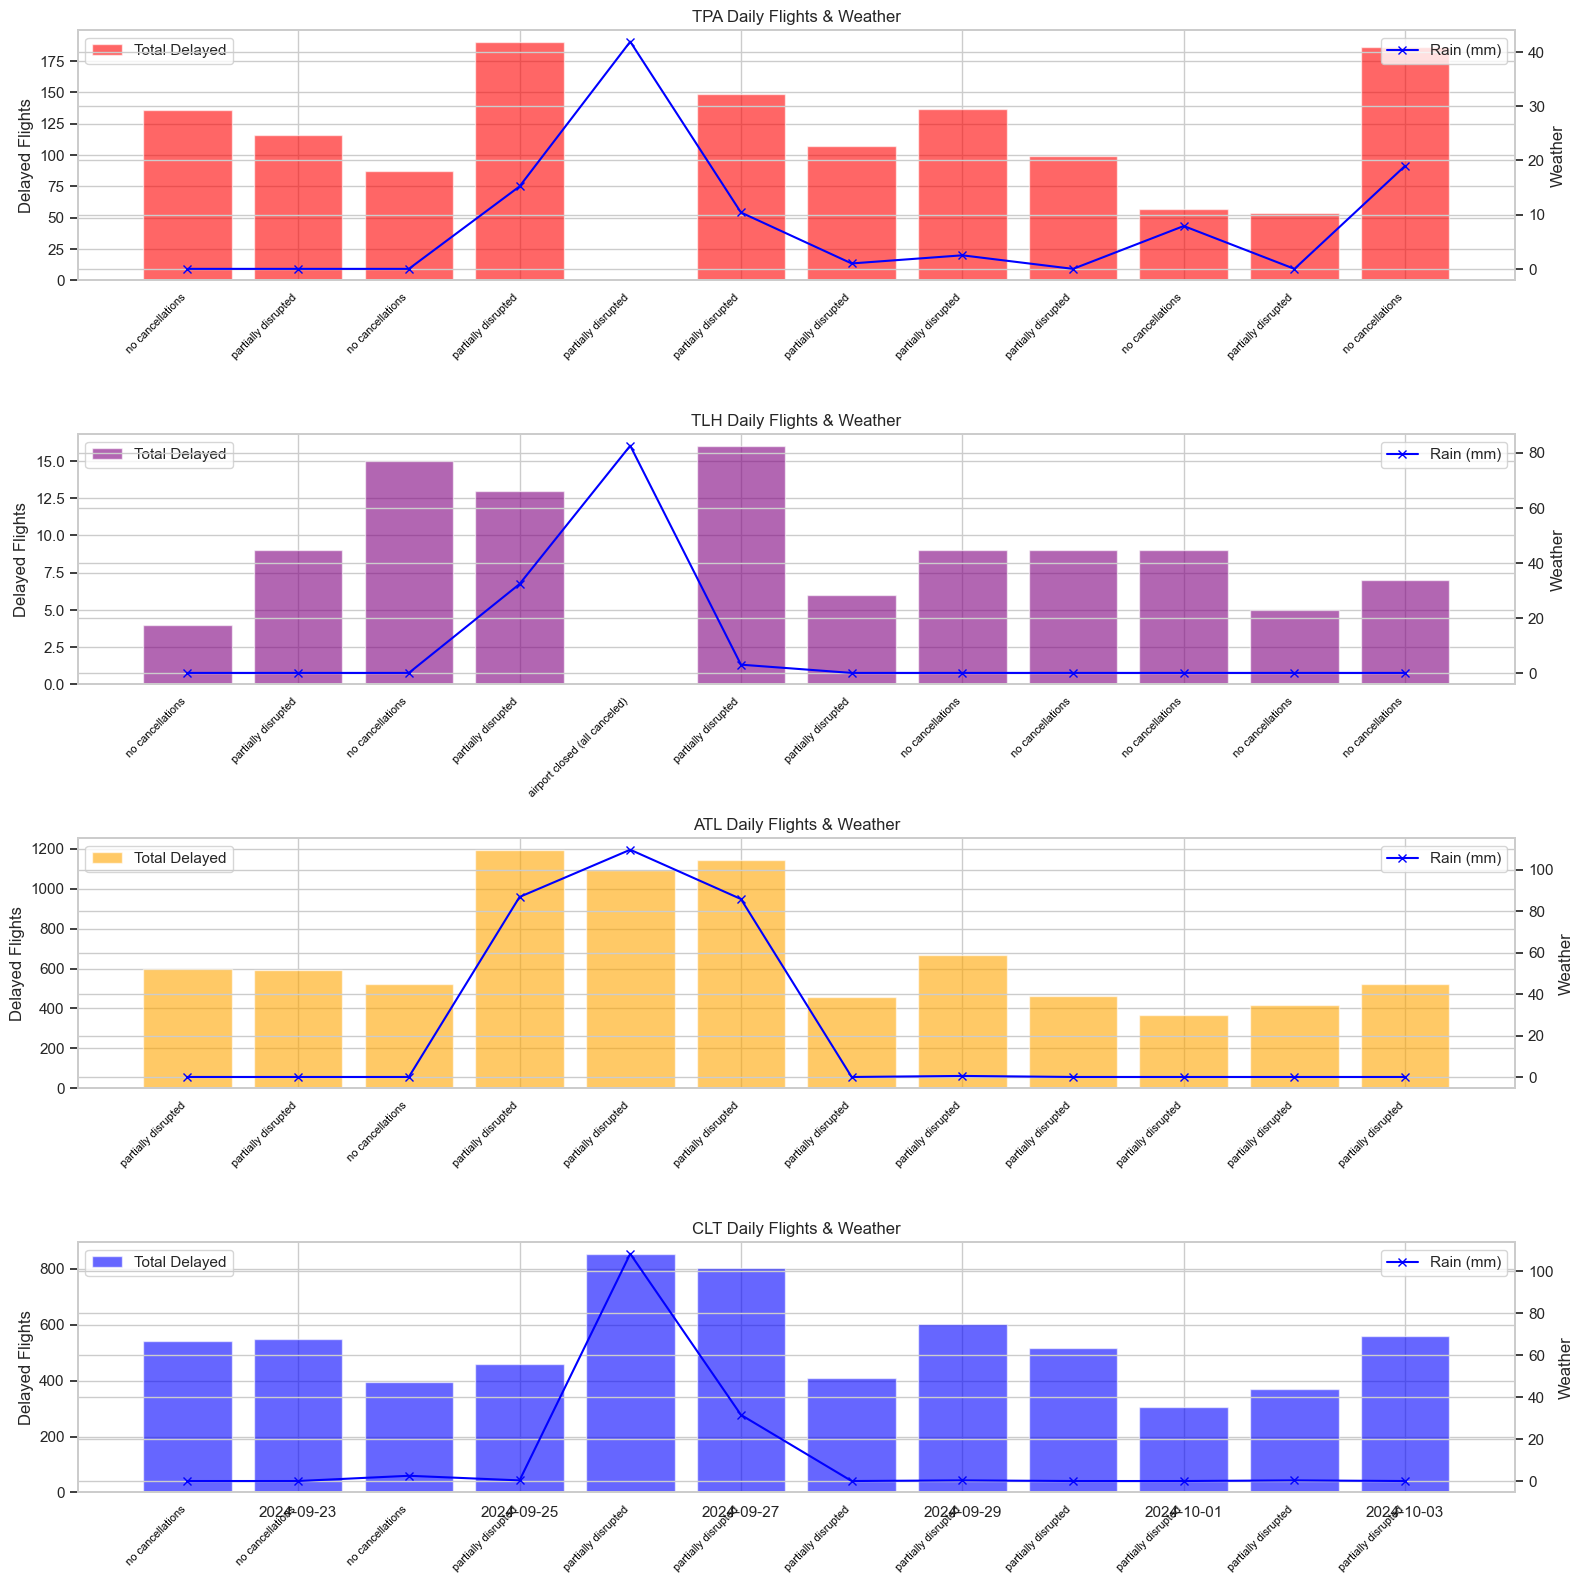

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import dotenv_values
import os

# ---- Load .env ----
config = dotenv_values()
pg_user = config['POSTGRES_USER']
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = quote_plus(config['POSTGRES_PASS'])

# ---- Create Engine ----
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'
engine = create_engine(url, echo=False)

# ---- Airports & Date Range ----
airports = ['TPA','TLH','ATL','CLT']
start_date = '2024-09-22'
end_date = '2024-10-03'

# ---- Load daily flights + weather ----
query = f"""
SELECT *
FROM {pg_schema}.mart_daily_flights_weather
WHERE airport IN ('{"','".join(airports)}')
  AND flight_date BETWEEN '{start_date}' AND '{end_date}'
ORDER BY airport, flight_date
"""
df = pd.read_sql(query, engine)

# ---- Ensure flight_date is datetime ----
df['flight_date'] = pd.to_datetime(df['flight_date'], errors='coerce')

# ---- Gesamtverzögerungen ----
df['total_delayed'] = df['dep_delayed_flight'] + df['arr_delayed_flight']

# ---- Plot: Subplots pro Airport ----
sns.set(style="whitegrid")
fig, axes = plt.subplots(len(airports), 1, figsize=(16, 4*len(airports)), sharex=True)

colors = {'TPA':'red','TLH':'purple','ATL':'orange','CLT':'blue'}

for i, airport in enumerate(airports):
    ax = axes[i]
    sub = df[df['airport'] == airport]
    
    # Balken: Total Delayed
    ax.bar(sub['flight_date'], sub['total_delayed'], color=colors[airport], alpha=0.6, label="Total Delayed")
    
    # Sekundärachse für Wetter
    ax2 = ax.twinx()
    if 'wind_speed_kmh' in sub.columns:
        ax2.plot(sub['flight_date'], sub['wind_speed_kmh'], color='green', marker='o', linestyle='--', label='Wind (km/h)')
    if 'precipitation_mm' in sub.columns:
        ax2.plot(sub['flight_date'], sub['precipitation_mm'], color='blue', marker='x', linestyle='-', label='Rain (mm)')
    
    # airport_status unten unterhalb der x-Achse
    if 'airport_status' in sub.columns:
        for idx, row in sub.iterrows():
            ax.text(row['flight_date'], -0.05*max(sub['total_delayed']),  # etwas unter 0
                    str(row['airport_status']),
                    rotation=45, fontsize=8, ha='right', va='top', color='black', clip_on=False)
    
    ax.set_ylabel("Delayed Flights")
    ax2.set_ylabel("Weather")
    ax.set_title(f"{airport} Daily Flights & Weather")
    
    # Legends
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

plt.xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()

# ---- Save Figure ----
os.makedirs("Nicole_test", exist_ok=True)
plt.savefig("Nicole_test/best_plot_daily_flights_weather_status_bottom.png", dpi=300)
plt.show()